<a href="https://colab.research.google.com/github/amyashima27-ops/C-lculo.Num-rico/blob/main/Ativ_3_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [144]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [145]:
def f1(x): return x**2 - 2
def df1(x): return 2*x
a1=1
b1=2
x01=1.5

def f2(x): return x**3 - x - 2
def df2(x): return 3*x**2 - 1
a2=1
b2=2
x02=1.5

def f3(x): return np.exp(-x) - x
def df3(x): return -np.exp(-x) - 1
a3=0
b3= 1
x03=0.5

def f4(x): return x**3 - 2*x + 2
def df4(x): return 3*x**2 - 2
a4=-2
b4=-1
x04=-2

In [146]:
def bissecao(funcao, a, b, tolerancia=1e-8, max_iter=100):
    # Método da bisseção com registro das iterações.
    if a >= b:
        raise ValueError("É necessário fornecer a < b.")
    if tolerancia <= 0 or max_iter < 1:
        raise ValueError("Use tolerância positiva e max_iter >= 1.")

    fa, fb = funcao(a), funcao(b)
    if not np.isfinite([fa, fb]).all():
        raise ValueError("A função não é finita nas extremidades.")
    if fa == 0:
        return a, pd.DataFrame(), "a é raiz"
    if fb == 0:
        return b, pd.DataFrame(), "b é raiz"
    if fa*fb > 0:
        raise ValueError("Não há mudança de sinal nas extremidades.")

    historico = []
    for k in range(1, max_iter+1):
        m = a + (b-a)/2
        fm = funcao(m)
        erro = (b-a)/2
        historico.append({
            "iteração": k, "a": a, "b": b, "m": m,
            "f(a)": fa, "f(m)": fm, "f(b)": fb,
            "erro máximo": erro
        })

        if fm == 0 or erro <= tolerancia:
            motivo = "raiz exata" if fm == 0 else "tolerância"
            break

        if fa*fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    else:
        raise RuntimeError("Número máximo de iterações atingido.")

    return m, pd.DataFrame(historico), motivo



raiz, historico, motivo = bissecao(f1, a1, b1, tolerancia=1e-8)
print(f"Raiz aproximada: {raiz:.12f}")
print(f"f1(raiz): {f1(raiz):.3e}")
print(f"Número de iterações: {len(historico)}")
print(f"Parada: {motivo}")
display(historico.head(6).round(8))

Raiz aproximada: 1.414213560522
f1(raiz): -5.237e-09
Número de iterações: 27
Parada: tolerância


,iteração,a,b,m,f(a),f(m),f(b),erro máximo
0,1,1.00000,2.0000,1.500000,-1.000000,0.250000,2.000000,0.500000
1,2,1.00000,1.5000,1.250000,-1.000000,-0.437500,0.250000,0.250000
2,3,1.25000,1.5000,1.375000,-0.437500,-0.109375,0.250000,0.125000
3,4,1.37500,1.5000,1.437500,-0.109375,0.066406,0.250000,0.062500
4,5,1.37500,1.4375,1.406250,-0.109375,-0.022461,0.066406,0.031250
5,6,1.40625,1.4375,1.421875,-0.022461,0.021729,0.066406,0.015625


In [147]:
raiz, historico, motivo = bissecao(f2, a2, b2, tolerancia=1e-8)

print(f"Raiz aproximada: {raiz:.12f}")
print(f"f2(raiz): {f2(raiz):.3e}")
print(f"Número de iterações: {len(historico)}")
print(f"Parada: {motivo}")
display(historico.head(6).round(8))

Raiz aproximada: 1.521379701793
f2(raiz): -2.979e-08
Número de iterações: 27
Parada: tolerância


,iteração,a,b,m,f(a),f(m),f(b),erro máximo
0,1,1.0,2.00000,1.500000,-2.000,-0.125000,4.000000,0.500000
1,2,1.5,2.00000,1.750000,-0.125,1.609375,4.000000,0.250000
2,3,1.5,1.75000,1.625000,-0.125,0.666016,1.609375,0.125000
3,4,1.5,1.62500,1.562500,-0.125,0.252197,0.666016,0.062500
4,5,1.5,1.56250,1.531250,-0.125,0.059113,0.252197,0.031250
5,6,1.5,1.53125,1.515625,-0.125,-0.034054,0.059113,0.015625


In [148]:
raiz, historico, motivo = bissecao(f3, a3, b3, tolerancia=1e-8)

print(f"Raiz aproximada: {raiz:.12f}")
print(f"f2(raiz): {f3(raiz):.3e}")
print(f"Número de iterações: {len(historico)}")
print(f"Parada: {motivo}")
display(historico.head(6).round(8))

Raiz aproximada: 0.567143283784
f2(raiz): 1.038e-08
Número de iterações: 27
Parada: tolerância


,iteração,a,b,m,f(a),f(m),f(b),erro máximo
0,1,0.0000,1.00000,0.500000,1.000000,0.106531,-0.632121,0.500000
1,2,0.5000,1.00000,0.750000,0.106531,-0.277633,-0.632121,0.250000
2,3,0.5000,0.75000,0.625000,0.106531,-0.089739,-0.277633,0.125000
3,4,0.5000,0.62500,0.562500,0.106531,0.007283,-0.089739,0.062500
4,5,0.5625,0.62500,0.593750,0.007283,-0.041498,-0.089739,0.031250
5,6,0.5625,0.59375,0.578125,0.007283,-0.017176,-0.041498,0.015625


In [149]:
raiz, historico, motivo = bissecao(f4, a4, b4, tolerancia=1e-8)

print(f"Raiz aproximada: {raiz:.12f}")
print(f"f2(raiz): {f4(raiz):.3e}")
print(f"Número de iterações: {len(historico)}")
print(f"Parada: {motivo}")
display(historico.head(6).round(8))

Raiz aproximada: -1.769292347133
f2(raiz): 5.252e-08
Número de iterações: 27
Parada: tolerância


,iteração,a,b,m,f(a),f(m),f(b),erro máximo
0,1,-2.00000,-1.00,-1.500000,-2.000000,1.625000,3.000000,0.500000
1,2,-2.00000,-1.50,-1.750000,-2.000000,0.140625,1.625000,0.250000
2,3,-2.00000,-1.75,-1.875000,-2.000000,-0.841797,0.140625,0.125000
3,4,-1.87500,-1.75,-1.812500,-0.841797,-0.329346,0.140625,0.062500
4,5,-1.81250,-1.75,-1.781250,-0.329346,-0.089142,0.140625,0.031250
5,6,-1.78125,-1.75,-1.765625,-0.089142,0.027035,0.140625,0.015625


In [150]:
import pandas as pd
def newton(f, df, x0, tol=1e-10, max_iter=50, deriv_tol=1e-14):
    """Resolve f(x)=0 pelo método de Newton e retorna raiz e histórico."""
    x = float(x0)
    historico = []

    for k in range(max_iter):
        fx = f(x)
        dfx = df(x)
        historico.append({"k": k, "x": x, "f(x)": fx, "f'(x)": dfx})

        if abs(fx) <= tol:
            return x, historico, "convergiu pelo resíduo"

        if abs(dfx) <= deriv_tol:
            return x, historico, "parou: derivada nula ou muito pequena"

        x_novo = x - fx / dfx

        # Um passo pequeno sem resíduo pequeno pode indicar estagnação.
        if abs(x_novo - x) <= tol * max(1.0, abs(x_novo)):
            x = x_novo
            if abs(f(x)) <= tol:
                historico.append({"k": k + 1, "x": x, "f(x)": f(x), "f'(x)": df(x)})
                return x, historico, "convergiu pelo resíduo após passo pequeno"
            return x, historico, "parou: passo pequeno, mas resíduo ainda alto"

        x = x_novo

    return x, historico, "parou: atingiu o máximo de iterações"

raiz_n, hist_n, estado_n = newton(f1, df1, x01)
print("Raiz aproximada:", raiz_n)
print("Resíduo:", abs(f1(raiz_n)))
print("Iterações registradas:", len(hist_n))
print("Estado:", estado_n)
pd.DataFrame(hist_n)

Raiz aproximada: 1.4142135623746899
Resíduo: 4.510614104447086e-12
Iterações registradas: 4
Estado: convergiu pelo resíduo


,k,x,f(x),f'(x)
0,0,1.500000,2.500000e-01,3.000000
1,1,1.416667,6.944444e-03,2.833333
2,2,1.414216,6.007305e-06,2.828431
3,3,1.414214,4.510614e-12,2.828427


In [151]:
raiz_n, hist_n, estado_n = newton(f2, df2, x02)
print("Raiz aproximada:", raiz_n)
print("Resíduo:", abs(f2(raiz_n)))
print("Iterações registradas:", len(hist_n))
print("Estado:", estado_n)
pd.DataFrame(hist_n)

Raiz aproximada: 1.5213797068045751
Resíduo: 4.529709940470639e-14
Iterações registradas: 4
Estado: convergiu pelo resíduo


,k,x,f(x),f'(x)
0,0,1.500000,-1.250000e-01,5.750000
1,1,1.521739,2.136928e-03,5.947070
2,2,1.521380,5.893874e-07,5.943790
3,3,1.521380,4.529710e-14,5.943789


In [152]:
raiz_n, hist_n, estado_n = newton(f3, df3, x03)
print("Raiz aproximada:", raiz_n)
print("Resíduo:", abs(f3(raiz_n)))
print("Iterações registradas:", len(hist_n))
print("Estado:", estado_n)
pd.DataFrame(hist_n)

Raiz aproximada: 0.5671432904097811
Resíduo: 4.440892098500626e-15
Iterações registradas: 4
Estado: convergiu pelo resíduo


,k,x,f(x),f'(x)
0,0,0.500000,1.065307e-01,-1.606531
1,1,0.566311,1.304510e-03,-1.567616
2,2,0.567143,1.964805e-07,-1.567143
3,3,0.567143,4.440892e-15,-1.567143


In [153]:
raiz_n, hist_n, estado_n = newton(f4, df4, x04)
print("Raiz aproximada:", raiz_n)
print("Resíduo:", abs(f4(raiz_n)))
print("Iterações registradas:", len(hist_n))
print("Estado:", estado_n)
pd.DataFrame(hist_n)

Raiz aproximada: -1.7692923542386998
Resíduo: 5.053735208093713e-13
Iterações registradas: 5
Estado: convergiu pelo resíduo


,k,x,f(x),f'(x)
0,0,-2.000000,-2.000000e+00,10.000000
1,1,-1.800000,-2.320000e-01,7.720000
2,2,-1.769948,-4.849662e-03,7.398150
3,3,-1.769293,-2.281418e-06,7.391190
4,4,-1.769292,-5.053735e-13,7.391186


In [154]:

def secantes(f, x0, x1, tol=1e-10, max_iter=50, denom_tol=1e-14):
    """Resolve f(x)=0 pelo método das secantes."""
    x_anterior = float(x0)
    x_atual = float(x1)
    historico = []

    for k in range(max_iter):
        f_anterior = f(x_anterior)
        f_atual = f(x_atual)
        historico.append({"k": k, "x": x_atual, "f(x)": f_atual})

        if abs(f_atual) <= tol:
            return x_atual, historico, "convergiu pelo resíduo"

        denominador = f_atual - f_anterior
        if abs(denominador) <= denom_tol:
            return x_atual, historico, "parou: denominador nulo ou muito pequeno"

        x_novo = x_atual - f_atual * (x_atual - x_anterior) / denominador

        if abs(x_novo - x_atual) <= tol * max(1.0, abs(x_novo)):
            if abs(f(x_novo)) <= tol:
                historico.append({"k": k + 1, "x": x_novo, "f(x)": f(x_novo)})
                return x_novo, historico, "convergiu pelo resíduo após passo pequeno"
            return x_novo, historico, "parou: passo pequeno, mas resíduo ainda alto"

        x_anterior, x_atual = x_atual, x_novo

    return x_atual, historico, "parou: atingiu o máximo de iterações"

raiz_s, hist_s, estado_s = secantes(f1, a1, b1)
print("Raiz aproximada:", raiz_s)
print("Resíduo:", abs(f1(raiz_s)))
print("Iterações registradas:", len(hist_s))
print("Estado:", estado_s)
pd.DataFrame(hist_s)


Raiz aproximada: 1.4142135623730954
Resíduo: 8.881784197001252e-16
Iterações registradas: 7
Estado: convergiu pelo resíduo


,k,x,f(x)
0,0,2.000000,2.000000e+00
1,1,1.333333,-2.222222e-01
2,2,1.400000,-4.000000e-02
3,3,1.414634,1.189768e-03
4,4,1.414211,-6.007287e-06
5,5,1.414214,-8.931456e-10
6,6,1.414214,8.881784e-16


In [155]:
raiz_s, hist_s, estado_s = secantes(f2, a2, b2)
print("Raiz aproximada:", raiz_s)
print("Resíduo:", abs(f2(raiz_s)))
print("Iterações registradas:", len(hist_s))
print("Estado:", estado_s)
pd.DataFrame(hist_s)

Raiz aproximada: 1.5213797068045645
Resíduo: 1.84297022087776e-14
Iterações registradas: 8
Estado: convergiu pelo resíduo


,k,x,f(x)
0,0,2.000000,4.000000e+00
1,1,1.333333,-9.629630e-01
2,2,1.462687,-3.333389e-01
3,3,1.531169,5.862642e-02
4,4,1.520926,-2.693300e-03
5,5,1.521376,-2.015019e-05
6,6,1.521380,7.015478e-09
7,7,1.521380,-1.842970e-14


In [156]:
raiz_s, hist_s, estado_s = secantes(f3, a3, b3)
print("Raiz aproximada:", raiz_s)
print("Resíduo:", abs(f3(raiz_s)))
print("Iterações registradas:", len(hist_s))
print("Estado:", estado_s)
pd.DataFrame(hist_s)

Raiz aproximada: 0.5671432904097046
Resíduo: 1.2423395645555502e-13
Iterações registradas: 6
Estado: convergiu pelo resíduo


,k,x,f(x)
0,0,1.000000,-6.321206e-01
1,1,0.612700,-7.081395e-02
2,2,0.563838,5.182355e-03
3,3,0.567170,-4.241924e-05
4,4,0.567143,-2.538017e-08
5,5,0.567143,1.242340e-13


In [157]:
raiz_s, hist_s, estado_s = secantes(f4, a4, b4)
print("Raiz aproximada:", raiz_s)
print("Resíduo:", abs(f4(raiz_s)))
print("Iterações registradas:", len(hist_s))
print("Estado:", estado_s)
pd.DataFrame(hist_s)

Raiz aproximada: -1.7692923542364172
Resíduo: 1.6365575561394508e-11
Iterações registradas: 8
Estado: convergiu pelo resíduo


,k,x,f(x)
0,0,-1.000000,3.000000e+00
1,1,-1.600000,1.104000e+00
2,2,-1.949367,-1.508923e+00
3,3,-1.747613,1.577521e-01
4,4,-1.766709,1.905774e-02
5,5,-1.769333,-3.011318e-04
6,6,-1.769292,5.593697e-07
7,7,-1.769292,1.636558e-11


In [158]:
import pandas as pd
import numpy as np

# 1. Definição das funções e derivadas do enunciado
def f1(x): return x**2 - 2
def df1(x): return 2*x

def f2(x): return x**3 - x - 2
def df2(x): return 3*x**2 - 1

def f3(x): return np.exp(-x) - x
def df3(x): return -np.exp(-x) - 1

def f4(x): return x**3 - 2*x + 2
def df4(x): return 3*x**2 - 2

# 2. Implementação dos Métodos Numéricos
def bissecao(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) > 0:
        return None, 0, [], "Erro: f(a)*f(b) > 0"
    historico = []
    for k in range(max_iter):
        c = (a + b) / 2.0
        historico.append((a, b, c))
        if abs(f(c)) < tol or (b - a)/2 < tol:
            return c, k + 1, historico, "Convergido"
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return c, max_iter, historico, "Falha: Max iter"

def newton(f, df, x0, tol=1e-6, max_iter=100):
    historico = [x0]
    xk = x0
    for k in range(max_iter):
        df_val = df(xk)
        if abs(df_val) < 1e-12:
            return xk, k, historico, "Erro: f'(x) ~ 0"
        x_next = xk - f(xk) / df_val
        historico.append(x_next)
        if abs(x_next - xk) < tol or abs(f(x_next)) < tol:
            return x_next, k + 1, historico, "Convergido"
        xk = x_next
    return xk, max_iter, historico, "Falha: Max iter"

def secante(f, x0, x1, tol=1e-6, max_iter=100):
    historico = [x0, x1]
    for k in range(max_iter):
        f0, f1_val = f(x0), f(x1)
        denominador = f1_val - f0
        if abs(denominador) < 1e-12:
            return x1, k, historico, "Erro: Denominador ~ 0"
        x2 = x1 - f1_val * (x1 - x0) / denominador
        historico.append(x2)
        if abs(x2 - x1) < tol or abs(f(x2)) < tol:
            return x2, k + 1, historico, "Convergido"
        x0, x1 = x1, x2
    return x1, max_iter, historico, "Falha: Max iter"

# 3. Função Principal para Gerar a Tabela Final
def gerar_tabela_completa(tol=1e-6, max_iter=100):
    testes = [
        {"nome": "f1(x) = x² - 2", "f": f1, "df": df1, "biss": [1.0, 2.0], "newt": 1.5, "sec": (1.0, 2.0)},
        {"nome": "f2(x) = x³ - x - 2", "f": f2, "df": df2, "biss": [1.0, 2.0], "newt": 1.5, "sec": (1.0, 2.0)},
        {"nome": "f3(x) = e^(-x) - x", "f": f3, "df": df3, "biss": [0.0, 1.0], "newt": 0.5, "sec": (0.0, 1.0)},
        {"nome": "f4(x) = x³ - 2x + 2", "f": f4, "df": df4, "biss": [-2.0, -1.0], "newt": -2.0, "sec": (-2.0, -1.0)},
    ]

    linhas = []

    for t in testes:
        f, df = t["f"], t["df"]

        # Bisseção
        a, b = t["biss"]
        raiz, iters, _, status = bissecao(f, a, b, tol, max_iter)
        res = abs(f(raiz)) if raiz is not None else np.nan
        linhas.append({
            "Função": t["nome"],
            "Método": "Bisseção",
            "Valores iniciais": f"[{a}, {b}]",
            "Raiz aproximada": f"{raiz:.6f}" if raiz is not None else "N/A",
            "|f(x)| final": f"{res:.2e}" if raiz is not None else "N/A",
            "Iterações/resultado": f"{iters} ({status})"
        })

        # Newton
        x0 = t["newt"]
        raiz, iters, _, status = newton(f, df, x0, tol, max_iter)
        res = abs(f(raiz)) if raiz is not None else np.nan
        linhas.append({
            "Função": t["nome"],
            "Método": "Newton",
            "Valores iniciais": f"x0 = {x0}",
            "Raiz aproximada": f"{raiz:.6f}" if raiz is not None else "N/A",
            "|f(x)| final": f"{res:.2e}" if raiz is not None else "N/A",
            "Iterações/resultado": f"{iters} ({status})"
        })

        # Secante
        x0, x1 = t["sec"]
        raiz, iters, _, status = secante(f, x0, x1, tol, max_iter)
        res = abs(f(raiz)) if raiz is not None else np.nan
        linhas.append({
            "Função": t["nome"],
            "Método": "Secante",
            "Valores iniciais": f"({x0}, {x1})",
            "Raiz aproximada": f"{raiz:.6f}" if raiz is not None else "N/A",
            "|f(x)| final": f"{res:.2e}" if raiz is not None else "N/A",
            "Iterações/resultado": f"{iters} ({status})"
        })

    return pd.DataFrame(linhas)

# Execução
df_tabela = gerar_tabela_completa()
display(df_tabela)

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² - 2,Bisseção,"[1.0, 2.0]",1.414214,1.62e-06,20 (Convergido)
1,f1(x) = x² - 2,Newton,x0 = 1.5,1.414214,4.51e-12,3 (Convergido)
2,f1(x) = x² - 2,Secante,"(1.0, 2.0)",1.414214,8.93e-10,5 (Convergido)
3,f2(x) = x³ - x - 2,Bisseção,"[1.0, 2.0]",1.521380,4.27e-06,20 (Convergido)
4,f2(x) = x³ - x - 2,Newton,x0 = 1.5,1.521380,5.89e-07,2 (Convergido)
5,f2(x) = x³ - x - 2,Secante,"(1.0, 2.0)",1.521380,7.02e-09,6 (Convergido)
6,f3(x) = e^(-x) - x,Bisseção,"[0.0, 1.0]",0.567143,2.35e-07,20 (Convergido)
7,f3(x) = e^(-x) - x,Newton,x0 = 0.5,0.567143,1.96e-07,2 (Convergido)
8,f3(x) = e^(-x) - x,Secante,"(0.0, 1.0)",0.567143,2.54e-08,4 (Convergido)
9,f4(x) = x³ - 2x + 2,Bisseção,"[-2.0, -1.0]",-1.769292,3.52e-06,20 (Convergido)


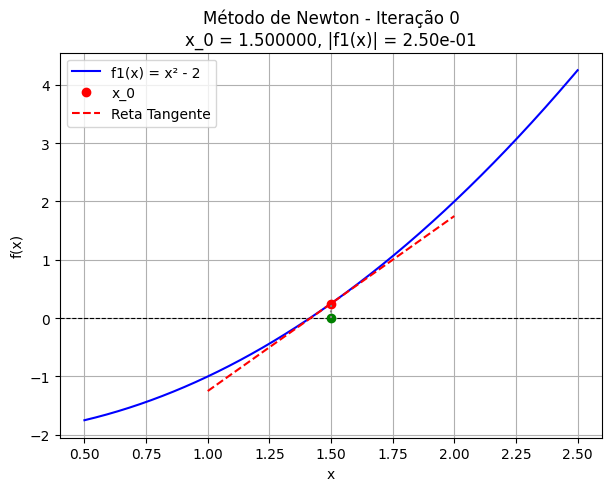

In [159]:
import matplotlib.animation as animation

root, iters, hist_x_values, status = newton(f1, df1, 1.5)

fig, ax = plt.subplots(figsize=(7, 5))
x_vals = np.linspace(0.5, 2.5, 400)
y_vals = f1(x_vals)

def update(frame):
    ax.clear()
    ax.plot(x_vals, y_vals, label='f1(x) = x² - 2', color='blue')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

    xk = hist_x_values[frame]
    yk = f1(xk)
    res = abs(yk)

    ax.plot(xk, yk, 'ro', label=f'x_{frame}')
    ax.plot(xk, 0, 'go')
    ax.vlines(xk, 0, yk, colors='gray', linestyles='dotted')

    # Tangent line
    slope = df1(xk)
    x_tangent = np.linspace(xk - 0.5, xk + 0.5, 10)
    y_tangent = yk + slope * (x_tangent - xk)
    ax.plot(x_tangent, y_tangent, 'r--', label='Reta Tangente')

    ax.set_title(f'Método de Newton - Iteração {frame}\nx_{frame} = {xk:.6f}, |f1(x)| = {res:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()
    ax.grid(True)

anim = animation.FuncAnimation(fig, update, frames=len(hist_x_values), interval=1000, repeat=False)
anim.save('newton.gif', writer='pillow', fps=1)

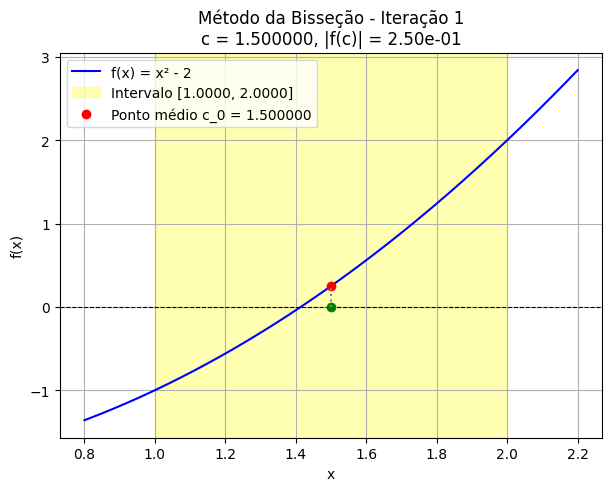

In [160]:
raiz_bis, iters_bis, hist_bis_data, status_bis = bissecao(f1, 1.0, 2.0)

fig, ax = plt.subplots(figsize=(7, 5))
x_vals = np.linspace(0.8, 2.2, 400)
y_vals = f1(x_vals)

def update_bis(frame):
    ax.clear()
    ax.plot(x_vals, y_vals, label='f(x) = x² - 2', color='blue')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

    a, b, c = hist_bis_data[frame]
    res = abs(f1(c))

    # Highlight interval [a, b]
    ax.axvspan(a, b, color='yellow', alpha=0.3, label=f'Intervalo [{a:.4f}, {b:.4f}]')
    ax.plot(c, f1(c), 'ro', label=f'Ponto médio c_{frame} = {c:.6f}')
    ax.plot(c, 0, 'go')
    ax.vlines(c, 0, f1(c), colors='gray', linestyles='dotted')

    ax.set_title(f'Método da Bisseção - Iteração {frame+1}\nc = {c:.6f}, |f(c)| = {res:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()
    ax.grid(True)

anim_bis = animation.FuncAnimation(fig, update_bis, frames=len(hist_bis_data), interval=1000, repeat=False)
anim_bis.save('test_bissecao.gif', writer='pillow', fps=1)

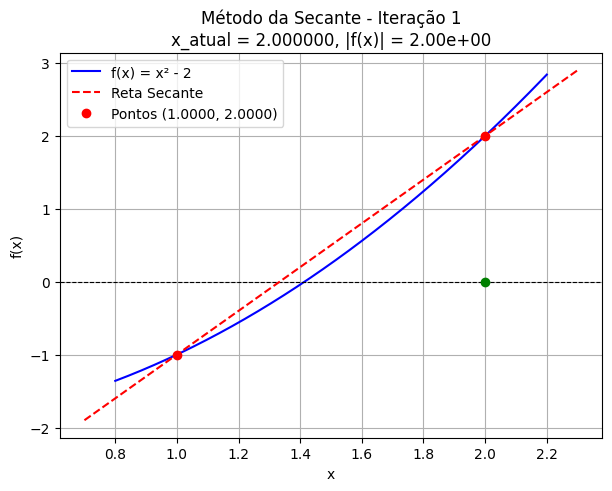

In [162]:
raiz_sec, iters_sec, hist_sec_data, status_sec = secante(f1, 1.0, 2.0)

fig, ax = plt.subplots(figsize=(7, 5))
x_vals = np.linspace(0.8, 2.2, 400)
y_vals = f1(x_vals)

def update_sec(frame):
    ax.clear()
    ax.plot(x_vals, y_vals, label='f(x) = x² - 2', color='blue')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

    # For each frame, we need two consecutive x-values from the history to draw the secant line.
    # hist_sec_data contains [x0_initial, x1_initial, x2, x3, ..., x_final].
    # So, for frame `k`, we use x_k and x_{k+1} to define the secant line.
    x_point_1 = hist_sec_data[frame]
    x_point_2 = hist_sec_data[frame + 1]

    y_point_1 = f1(x_point_1)
    y_point_2 = f1(x_point_2)

    # The 'latest' root approximation for display in this iteration is x_point_2
    res = abs(y_point_2)

    # Secant line passing through (x_point_1, y_point_1) and (x_point_2, y_point_2)
    if (x_point_2 - x_point_1) == 0:
        # This case should ideally not happen in a well-behaved secant method for distinct initial points.
        # If it does, a vertical line or error handling might be needed.
        slope = np.nan # Or handle appropriately
    else:
        slope = (y_point_2 - y_point_1) / (x_point_2 - x_point_1)

    # Extend the secant line for visualization
    x_sec = np.linspace(min(x_vals.min(), x_point_1, x_point_2) - 0.1, max(x_vals.max(), x_point_1, x_point_2) + 0.1, 100)
    y_sec = y_point_2 + slope * (x_sec - x_point_2)

    ax.plot(x_sec, y_sec, 'r--', label='Reta Secante')
    ax.plot(x_point_1, y_point_1, 'ro')
    ax.plot(x_point_2, y_point_2, 'ro', label=f'Pontos ({x_point_1:.4f}, {x_point_2:.4f})')
    ax.plot(x_point_2, 0, 'go') # Mark the current x-approximation on the x-axis

    ax.set_title(f'Método da Secante - Iteração {frame+1}\nx_atual = {x_point_2:.6f}, |f(x)| = {res:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend()
    ax.grid(True)

# The number of frames should be len(hist_sec_data) - 1, as each frame uses hist_sec_data[frame] and hist_sec_data[frame+1].
# For N data points, there are N-1 secant segments.
anim_sec = animation.FuncAnimation(fig, update_sec, frames=len(hist_sec_data) - 1, interval=1000, repeat=False)
anim_sec.save('test_secante.gif', writer='pillow', fps=1)